# KNN ( K - Nearest Neighbour )

In [1]:
# jb bhut large dataset ho... missing values ho bhut tb ,..... or jb bhut fast prediction krni ho tb bhi..... KNN use nhi krna...

In [2]:
import pandas as pd

In [3]:
df = pd.read_csv("Social_Network_Ads.csv")

In [4]:
df.head()

,User ID,Gender,Age,EstimatedSalary,Purchased
0,15624510,Male,19,19000,0
1,15810944,Male,35,20000,0
2,15668575,Female,26,43000,0
3,15603246,Female,27,57000,0
4,15804002,Male,19,76000,0


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 5 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   User ID          400 non-null    int64 
 1   Gender           400 non-null    object
 2   Age              400 non-null    int64 
 3   EstimatedSalary  400 non-null    int64 
 4   Purchased        400 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 15.8+ KB


In [6]:
df.isnull().sum()

User ID            0
Gender             0
Age                0
EstimatedSalary    0
Purchased          0
dtype: int64

In [7]:
df.duplicated().sum()

np.int64(0)

In [8]:
Y = df["Purchased"]

In [9]:
X = df[["Age","EstimatedSalary"]]

In [10]:
X

,Age,EstimatedSalary
0,19,19000
1,35,20000
2,26,43000
3,27,57000
4,19,76000
...,...,...
395,46,41000
396,51,23000
397,50,20000
398,36,33000


In [11]:
Y

0      0
1      0
2      0
3      0
4      0
      ..
395    1
396    1
397    1
398    0
399    1
Name: Purchased, Length: 400, dtype: int64

In [12]:
import seaborn as sns
import matplotlib.pyplot as plt

<Figure size 200x200 with 0 Axes>

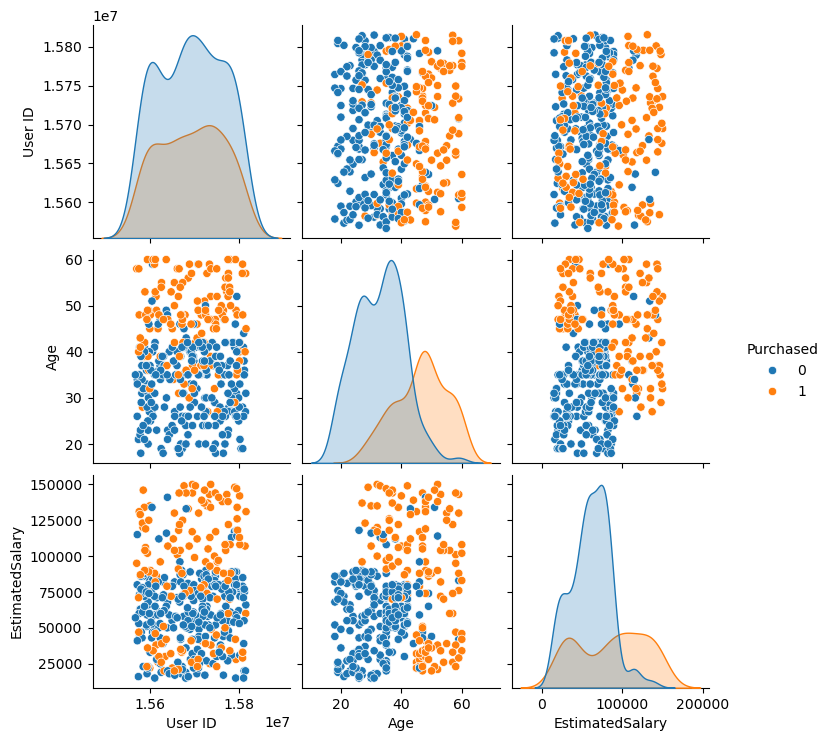

In [13]:
plt.figure(figsize=(2,2))
sns.pairplot(df,hue = "Purchased")

In [14]:
from sklearn.model_selection import train_test_split

In [15]:
X_train, X_test, Y_train, Y_test = train_test_split(X,Y, test_size = 0.20,random_state = 43)

In [16]:
X_train.head()

,Age,EstimatedSalary
332,42,65000
195,34,43000
26,49,28000
117,36,52000
157,29,75000


In [17]:
from sklearn.preprocessing import StandardScaler

In [18]:
sc = StandardScaler()

In [19]:
X_train = sc.fit_transform(X_train)

In [20]:
X_test = sc.fit_transform(X_test)

In [21]:
from sklearn.neighbors import KNeighborsClassifier

In [22]:
classifier = KNeighborsClassifier(
    n_neighbors=5, metric="minkowski", p=2
)

In [23]:
classifier

,n_neighbors,5
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


In [24]:
classifier.fit(X_train, Y_train)

,n_neighbors,5
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


In [25]:
Y_pred = classifier.predict(X_test)

In [26]:
result = pd.DataFrame({
    "Actual": Y_test,
    "Predicted": Y_pred
})

In [27]:
result.head(10)

,Actual,Predicted
55,0,0
271,1,1
390,1,1
105,0,0
223,1,1
358,1,0
20,1,1
309,0,0
395,1,1
139,0,0


In [28]:
from sklearn.metrics import confusion_matrix , accuracy_score

In [29]:
cm = confusion_matrix(Y_test, Y_pred)

In [30]:
cm

array([[43,  7],
       [ 6, 24]])

In [31]:
accuracy = accuracy_score(Y_test, Y_pred)
print(accuracy * 100)

83.75


In [32]:
from sklearn.linear_model import LogisticRegression

In [33]:
log_model = LogisticRegression(random_state = 0)

In [34]:
log_model.fit(X_train, Y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,0
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [35]:
log_predict = log_model.predict(X_test)

In [36]:
cm_log = confusion_matrix(Y_test, log_predict)

In [37]:
log_accuracy = accuracy_score(Y_test, log_predict)
print(log_accuracy * 100)

78.75


In [38]:
from sklearn.tree import DecisionTreeClassifier

In [39]:
DT_model = DecisionTreeClassifier(random_state=0)

In [40]:
DT_train_model = DT_model.fit(X_train, Y_train)

In [41]:
Y_pred = DT_model.predict(X_test)

In [42]:
result = pd.DataFrame({"Actual": Y_test,"Predicted": Y_pred})

result.head()

,Actual,Predicted
55,0,0
271,1,1
390,1,1
105,0,0
223,1,1


In [43]:
print("Accuracy:", accuracy_score(Y_test, Y_pred))

Accuracy: 0.8


In [44]:
from sklearn.metrics import classification_report

print(classification_report(Y_test, Y_pred))

              precision    recall  f1-score   support

           0       0.85      0.82      0.84        50
           1       0.72      0.77      0.74        30

    accuracy                           0.80        80
   macro avg       0.79      0.79      0.79        80
weighted avg       0.80      0.80      0.80        80

